<a href="https://colab.research.google.com/github/tukun29/PredictModBreastCancerPredictor/blob/main/HIVEBreastCancerPredictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

These are the imports needed to do the code

In [ ]:
### Imports / Setup

import numpy as np
import pandas as pd

!pip install GEOparse
import GEOparse

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

from google.colab import files
uploaded = files.upload()
print(sklearn.version)


Saving GSE25055_family.soft.gz to GSE25055_family.soft.gz


NameError: name 'sklearn' is not defined

Now that the soft file has been uploaded, it gets saved under pmid_soft as the variable

In [ ]:
pmid_soft = GEOparse.get_GEO(filepath="GSE25055_family.soft.gz")
print("loaded")

#additioal checks
print(type(pmid_soft))
print(len(pmid_soft.gsms))
print(pmid_soft.gpls.keys())

15-Apr-2026 14:20:36 INFO GEOparse - Parsing GSE25055_family.soft.gz: 
INFO:GEOparse:Parsing GSE25055_family.soft.gz: 
15-Apr-2026 14:20:36 DEBUG GEOparse - DATABASE: GeoMiame
DEBUG:GEOparse:DATABASE: GeoMiame
15-Apr-2026 14:20:36 DEBUG GEOparse - SERIES: GSE25055
DEBUG:GEOparse:SERIES: GSE25055
15-Apr-2026 14:20:36 DEBUG GEOparse - PLATFORM: GPL96
DEBUG:GEOparse:PLATFORM: GPL96
15-Apr-2026 14:20:37 DEBUG GEOparse - SAMPLE: GSM615096
DEBUG:GEOparse:SAMPLE: GSM615096
15-Apr-2026 14:20:37 DEBUG GEOparse - SAMPLE: GSM615097
DEBUG:GEOparse:SAMPLE: GSM615097
15-Apr-2026 14:20:37 DEBUG GEOparse - SAMPLE: GSM615098
DEBUG:GEOparse:SAMPLE: GSM615098
15-Apr-2026 14:20:37 DEBUG GEOparse - SAMPLE: GSM615099
DEBUG:GEOparse:SAMPLE: GSM615099
15-Apr-2026 14:20:37 DEBUG GEOparse - SAMPLE: GSM615100
DEBUG:GEOparse:SAMPLE: GSM615100
15-Apr-2026 14:20:37 DEBUG GEOparse - SAMPLE: GSM615101
DEBUG:GEOparse:SAMPLE: GSM615101
15-Apr-2026 14:20:37 DEBUG GEOparse - SAMPLE: GSM615102
DEBUG:GEOparse:SAMPLE: GSM61

loaded
<class 'GEOparse.GEOTypes.GSE'>
310
dict_keys(['GPL96'])


Extracting the Meta-data: "data about data" gives us the type of data points sitting in the SOFT file
The code prints the columns that exist in the metadata some of the data is useful some of it is not. Seeing a list helps us identify that
The SHAPE of the metadata tells us its dimensions. In this case: 310, 25 indicates there are 310 rows and 35 colums. 35 characterisics for 310 total samples. We should also see the DRFS binary property show up becyase that property actuall gives us the resulting 1 or 0 that tells the code whether the paitient actually made it through treatment or relapsed.

In [ ]:
# EXTRACT METADATA
metadata_list = []

for sample_name, sample in pmid_soft.gsms.items():
    row = {"sample_id": sample_name}

    for key, value in sample.metadata.items():
        # Keep full metadata as readable strings
        if isinstance(value, list):
            row[key] = " | ".join(map(str, value))

            # ALSO split things like "drfs_1_event_0_censored: 1"
            for item in value:
                if ":" in item:
                    k, v = item.split(":", 1)
                    clean_key = k.strip().lower().replace(" ", "_")
                    row[clean_key] = v.strip()
        else:
            row[key] = value

    metadata_list.append(row)

metadata_df = pd.DataFrame(metadata_list)

print("Metadata shape:", metadata_df.shape)
print("\nMetadata columns:")
print(metadata_df.columns.tolist())

Metadata shape: (310, 61)

Metadata columns:
['sample_id', 'title', 'geo_accession', 'status', 'submission_date', 'last_update_date', 'type', 'channel_count', 'source_name_ch1', 'organism_ch1', 'taxid_ch1', 'characteristics_ch1', 'source', 'age_years', 'er_status_ihc', 'pr_status_ihc', 'her2_status', 'er_status_ihc_esr1_for_indeterminate', 'clinical_t_stage', 'clinical_nodal_status', 'clinical_ajcc_stage', 'grade', 'pathologic_response_pcr_rd', 'pathologic_response_rcb_class', 'drfs_1_event_0_censored', 'drfs_even_time_years', 'esr1_status', 'erbb2_status', 'set_class', 'chemosensitivity_prediction', 'ggi_class', 'pam50_class', 'dlda30_prediction', 'rcb_0_i_prediction', 'tissue', 'treatment_protocol_ch1', 'molecule_ch1', 'extract_protocol_ch1', 'label_ch1', 'label_protocol_ch1', 'hyb_protocol', 'scan_protocol', 'data_processing', 'probe_intensities_were_quantified_with_microarray_suite_version_5.0_(mas_5.0)_using_affymetrix_default_analysis_settings.__cel_files_were_normalized_using_gl

Now we are going to identify the numeric (useful) data from the SOFT.file. Instead of looking at the metadate we go to the "table" layer/component of the file which the code will search through based on the VALUE parameter to pull the numeric data. The VALUE parmeter is the standardized parameter for GEO
files.

In [ ]:
print("\nExtracting expression matrix...")
expression_df = pmid_soft.pivot_samples("VALUE")

print("Original shape (genes x samples):", expression_df.shape)

# GEOparse usually gives rows = probes, columns = samples
# We want rows = samples, columns = probes
expression_df = expression_df.T

print("Transposed shape (samples x probes):", expression_df.shape)
print(expression_df)


Extracting expression matrix...
Original shape (genes x samples): (22283, 310)
Transposed shape (samples x probes): (310, 22283)
ID_REF     1007_s_at   1053_at    117_at     121_at  1255_g_at    1294_at  \
name                                                                        
GSM615096  12.359267  8.021741  8.294244  10.840949   7.874062   8.341292   
GSM615097  12.613243  7.842947  5.474758  11.715159   7.347955   9.419005   
GSM615098  11.551397  8.776267  8.197121  10.715077   6.523880   9.297479   
GSM615099  11.828700  9.523877  7.907263  10.750475   6.478643   8.698516   
GSM615100  11.983987  6.836237  8.625010  10.827725   7.336754   9.599059   
...              ...       ...       ...        ...        ...        ...   
GSM615401  12.135865  8.633192  9.783710   9.830411   7.357560   8.217632   
GSM615402  11.982492  9.451202  8.210670   9.354246   7.178217   9.082518   
GSM615403  11.721887  8.955527  8.980073  10.727569   8.242348   9.691482   
GSM615404  11.066133  9

Mapping the data back and renaimig things to be a bit more clearer and biologically meaningful to the average person (me).

In [ ]:
# MAP PROBE IDs TO GENE SYMBOLS

gpl = pmid_soft.gpls["GPL96"]
annotation = gpl.table

print("Annotation columns:")
print(annotation.columns.tolist())

# Some rows may have missing gene symbols
annotation = annotation[["ID", "Gene Symbol"]].copy()
annotation["Gene Symbol"] = annotation["Gene Symbol"].fillna("").astype(str).str.strip()

id_to_gene = dict(zip(annotation["ID"], annotation["Gene Symbol"]))

# Replace probe IDs with gene symbols when possible
new_columns = []
for col in expression_df.columns:
    gene = id_to_gene.get(col, "")
    if gene == "" or gene == "---":
        new_columns.append(col)   # keep probe ID if no gene symbol
    else:
        new_columns.append(gene)

expression_df.columns = new_columns

Annotation columns:
['ID', 'GB_ACC', 'SPOT_ID', 'Species Scientific Name', 'Annotation Date', 'Sequence Type', 'Sequence Source', 'Target Description', 'Representative Public ID', 'Gene Title', 'Gene Symbol', 'ENTREZ_GENE_ID', 'RefSeq Transcript ID', 'Gene Ontology Biological Process', 'Gene Ontology Cellular Component', 'Gene Ontology Molecular Function']


Now that the drfs event is visible we have to clean and integrate it to the matrix


In [ ]:
# REBUILD EXPRESSION MATRIX
expression_df = pmid_soft.pivot_samples("VALUE")

print("Original shape (genes x samples):", expression_df.shape)

expression_df = expression_df.T

print("Transposed shape (samples x probes):", expression_df.shape)
print("\nExpression sample IDs:")
print(expression_df.index[:10])

Original shape (genes x samples): (22283, 310)
Transposed shape (samples x probes): (310, 22283)

Expression sample IDs:
Index(['GSM615096', 'GSM615097', 'GSM615098', 'GSM615099', 'GSM615100',
       'GSM615101', 'GSM615102', 'GSM615103', 'GSM615104', 'GSM615105'],
      dtype='object', name='name')


In [ ]:
# CLEAN EXPRESSION INDEX
expression_df.index = expression_df.index.astype(str).str.strip()

In [ ]:
# FIND DRFS COLUMNS
drfs_cols = [col for col in metadata_df.columns if "drfs" in col.lower()]
print("\nColumns containing 'drfs':")
print(drfs_cols)


Columns containing 'drfs':
['drfs_1_event_0_censored', 'drfs_even_time_years']


In [ ]:
# CLEAN DRFS LABEL
metadata_df["drfs_1_event_0_censored"] = pd.to_numeric(
    metadata_df["drfs_1_event_0_censored"],
    errors="coerce"
)

print("\nDRFS value counts:")
print(metadata_df["drfs_1_event_0_censored"].value_counts(dropna=False))


DRFS value counts:
drfs_1_event_0_censored
0    244
1     66
Name: count, dtype: int64


In [ ]:
# SEARCH FOR THE CORRECT MATCHING ID COLUMN
matching_col = None

for col in metadata_df.columns:
    values = metadata_df[col].astype(str).str.strip()
    overlap = len(set(values) & set(expression_df.index))

    if overlap > 0:
        print(f"\nColumn '{col}' has {overlap} matching sample IDs.")

        # print a few example matches
        matches = list(set(values) & set(expression_df.index))[:10]
        print("Example matches:", matches)

        if matching_col is None:
            matching_col = col

print("\nChosen matching column:", matching_col)


# STOP IF NO MATCH FOUND
if matching_col is None:
    raise ValueError("No metadata column matches expression_df sample IDs. Need to inspect metadata_df manually.")


Column 'geo_accession' has 310 matching sample IDs.
Example matches: ['GSM615264', 'GSM615392', 'GSM615391', 'GSM615194', 'GSM615389', 'GSM615198', 'GSM615327', 'GSM615377', 'GSM615163', 'GSM615385']

Chosen matching column: geo_accession


In [ ]:
# BUILD LABEL TABLE USING THE MATCHING COLUMN
labels = metadata_df[[matching_col, "drfs_1_event_0_censored"]].dropna()
labels = labels.rename(columns={matching_col: "match_id"})
labels["match_id"] = labels["match_id"].astype(str).str.strip()
labels = labels.set_index("match_id")

print("\nLabels shape:", labels.shape)
print(labels.head())

print("\nLabel sample IDs:")
print(labels.index[:10])


Labels shape: (310, 1)
           drfs_1_event_0_censored
match_id                          
GSM615096                        1
GSM615097                        0
GSM615098                        0
GSM615099                        0
GSM615100                        1

Label sample IDs:
Index(['GSM615096', 'GSM615097', 'GSM615098', 'GSM615099', 'GSM615100',
       'GSM615101', 'GSM615102', 'GSM615103', 'GSM615104', 'GSM615105'],
      dtype='object', name='match_id')


In [ ]:
# BUILD LABEL TABLE USING THE MATCHING COLUMN
labels = metadata_df[[matching_col, "drfs_1_event_0_censored"]].dropna()
labels = labels.rename(columns={matching_col: "match_id"})
labels["match_id"] = labels["match_id"].astype(str).str.strip()
labels = labels.set_index("match_id")

print("\nLabels shape:", labels.shape)
print(labels.head())

print("\nLabel sample IDs:")
print(labels.index[:10])


Labels shape: (310, 1)
           drfs_1_event_0_censored
match_id                          
GSM615096                        1
GSM615097                        0
GSM615098                        0
GSM615099                        0
GSM615100                        1

Label sample IDs:
Index(['GSM615096', 'GSM615097', 'GSM615098', 'GSM615099', 'GSM615100',
       'GSM615101', 'GSM615102', 'GSM615103', 'GSM615104', 'GSM615105'],
      dtype='object', name='match_id')


In [ ]:
# FIND OVERLAPPING SAMPLES
common_samples = expression_df.index.intersection(labels.index)

print("\nNumber of matching samples:", len(common_samples))
print("First few matching sample IDs:")
print(common_samples[:10])


# KEEP ONLY MATCHED SAMPLES
expression_df_matched = expression_df.loc[common_samples]
labels_matched = labels.loc[common_samples]


Number of matching samples: 310
First few matching sample IDs:
Index(['GSM615096', 'GSM615097', 'GSM615098', 'GSM615099', 'GSM615100',
       'GSM615101', 'GSM615102', 'GSM615103', 'GSM615104', 'GSM615105'],
      dtype='object')


In [ ]:
# MERGE EXPRESSION + LABELS
final_df = expression_df_matched.merge(
    labels_matched,
    left_index=True,
    right_index=True
)

print("\nFinal dataset shape:", final_df.shape)
print(final_df.head())


Final dataset shape: (310, 22284)
           1007_s_at   1053_at    117_at     121_at  1255_g_at   1294_at  \
GSM615096  12.359267  8.021741  8.294244  10.840949   7.874062  8.341292   
GSM615097  12.613243  7.842947  5.474758  11.715159   7.347955  9.419005   
GSM615098  11.551397  8.776267  8.197121  10.715077   6.523880  9.297479   
GSM615099  11.828700  9.523877  7.907263  10.750475   6.478643  8.698516   
GSM615100  11.983987  6.836237  8.625010  10.827725   7.336754  9.599059   

            1316_at   1320_at  1405_i_at   1431_at  ...  AFFX-r2-Ec-bioD-5_at  \
GSM615096  8.256335  6.485966   6.495728  7.063123  ...             15.441187   
GSM615097  7.983681  7.330512   7.332244  7.033859  ...             16.383235   
GSM615098  7.820261  6.423794  10.066291  6.661108  ...             14.637426   
GSM615099  7.526617  7.276040  10.399704  6.642930  ...             14.218011   
GSM615100  8.312127  6.832232   7.090151  7.081613  ...             14.816849   

           AFFX-r2-Hs

Now the dataset if FINALLYYY properly created and can be used to train a model.

In [ ]:
# SPLIT FEATURES + TARGET
X = final_df.drop(columns=["drfs_1_event_0_censored"])
y = final_df["drfs_1_event_0_censored"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts())


# FEATURE REDUCTION
gene_variance = X.var(axis=0)
top_genes = gene_variance.sort_values(ascending=False).head(1000).index
X = X[top_genes]

print("\nReduced feature count:", X.shape[1])


# NORMALIZATION
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTraining set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


# MODEL
model = LogisticRegression(
    C=100,
    penalty=11,
    solver='liblinear',
    max_iter=500,
    class_weight='balanced'
)

model.fit(X_train, y_train)


# EVALUATION
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

metrics = {
    "accuracy": accuracy_score(y_test, y_pred),
    "precision": precision_score(y_test, y_pred),
    "recall": recall_score(y_test, y_pred),
    "f1": f1_score(y_test, y_pred),
    "auc": roc_auc_score(y_test, y_prob)
}

print("\nModel Performance:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")


# FEATURE IMPORTANCE
feature_importance = pd.Series(
    model.coef_[0],
    index=X.columns
).sort_values(key=abs, ascending=False)

print("\nTop Features:")
print(feature_importance.head(10))

NameError: name 'final_df' is not defined

Now we visualize the results so that the model can be improved

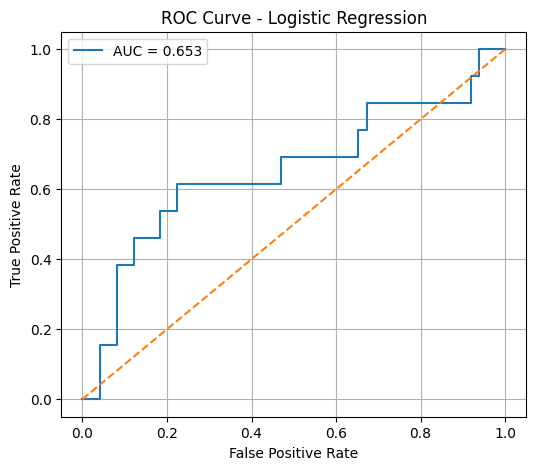

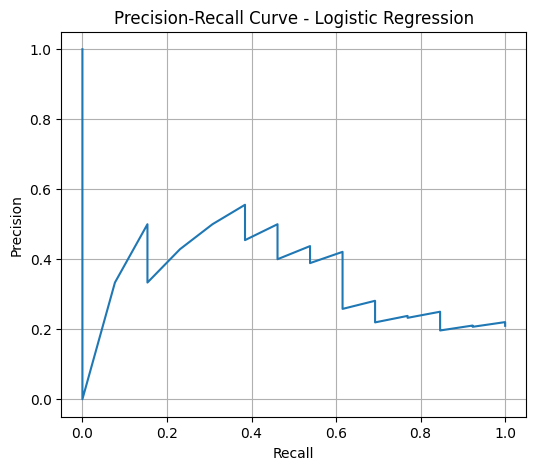

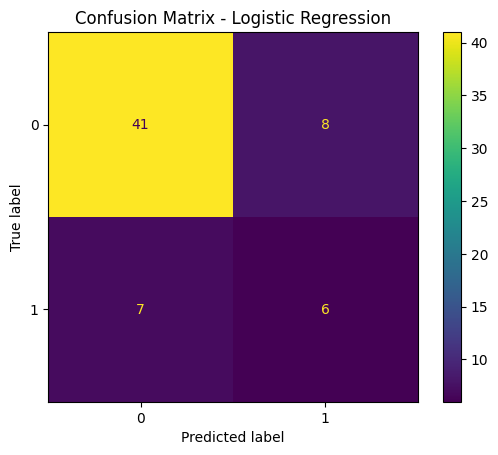

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ROC CURVE
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()

# PRECISION-RECALL CURVE
precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6, 5))
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")
plt.grid(True)
plt.show()


# CONFUSION MATRIX
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [ ]:
# GETTING THE BIOLOGICAL GENES

top_features = feature_importance.head(10)

def clean_gene_symbol(gene):
    if pd.isna(gene) or gene == "---":
        return "Unknown"
    return gene.split("///")[0].strip()

mapped_genes = [
    clean_gene_symbol(id_to_gene.get(probe, "Unknown"))
    for probe in top_features.index
]

df_top = pd.DataFrame({
    "Probe": top_features.index,
    "Gene": mapped_genes,
    "Coefficient": top_features.values
})

print(df_top)

         Probe       Gene  Coefficient
0    204540_at     EEF1A2     1.518858
1  211737_x_at        PTN    -1.278893
2  218885_s_at    GALNT12    -1.155978
3    220084_at  C14orf105    -1.058550
4    207147_at       DLX2     1.039317
5    202989_at       RGS1    -1.022044
6  215112_x_at     MCF2L2     1.000583
7  211078_s_at       STK3     0.987127
8    217595_at      GSPT1     0.922447
9    205916_at     S100A7     0.906573
